# Исходный датасет

Используется набор **Moscow Housing Price Dataset**.

Файл:
moscow-housing-price-dataset.csv

В проверенном файле:

- **22 676 строк**;
- **12 исходных столбцов**;
- Москва и Московская область;
- вторичный рынок и новостройки.

Основные поля:

| Поле | Смысл |
|---|---|
| `Price` | цена объекта |
| `Apartment type` | тип рынка |
| `Metro station` | ближайшая станция метро |
| `Minutes to metro` | время до метро, мин |
| `Region` | Москва / Московская область |
| `Number of rooms` | число комнат; значение `0` требует отдельной интерпретации |
| `Area` | общая площадь, м² |
| `Living area` | жилая площадь, м² |
| `Kitchen area` | площадь кухни, м² |
| `Floor` | этаж |
| `Number of floors` | этажность дома |
| `Renovation` | тип ремонта |

## Важное ограничение

Это **объявления**, а не зарегистрированные сделки.

Поэтому корректная формулировка:

> «в рассматриваемых объявлениях квартиры с такой характеристикой имеют более высокий уровень цены».

Некорректная формулировка:

> «эта характеристика вызывает рост рыночной цены».

Также в наборе нет уникального идентификатора объявления. Поэтому полностью совпадающие строки следует рассматривать как **потенциальные дубликаты**, но автоматически утверждать, что это одно и то же объявление, нельзя.


In [ ]:
# Постановка задачи
Руководству нужен краткий ответ на вопросы:

1. Насколько различается рынок Москвы и Московской области?
2. Какие сегменты рынка наиболее массовые?
3. Как удобнее сравнивать объекты — по общей цене или цене за квадратный метр?
4. Связаны ли цена за м², площадь, число комнат, ремонт и близость к метро?
5. Какие сегменты выглядят наиболее дорогими?
6. Какие выводы нельзя делать только на основании данного датасета?


In [10]:
path = r'C:\File\moscow-housing-price-dataset.csv'

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(path)
df.head()

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
0,6300000.0,Secondary,Опалиха,6.0,Moscow region,1.0,30.6,11.1,8.5,25.0,25,Cosmetic
1,9000000.0,Secondary,Павшино,2.0,Moscow region,1.0,49.2,20.0,10.0,6.0,15,European-style renovation
2,11090000.0,Secondary,Мякинино,14.0,Moscow region,1.0,44.7,16.2,13.1,10.0,25,Cosmetic
3,8300000.0,Secondary,Строгино,8.0,Moscow region,1.0,35.1,16.0,11.0,12.0,33,European-style renovation
4,6450000.0,Secondary,Опалиха,6.0,Moscow region,1.0,37.7,15.2,4.0,5.0,5,Without renovation


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22676 entries, 0 to 22675
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             22676 non-null  float64
 1   Apartment type    22676 non-null  str    
 2   Metro station     22676 non-null  str    
 3   Minutes to metro  22676 non-null  float64
 4   Region            22676 non-null  str    
 5   Number of rooms   22676 non-null  float64
 6   Area              22676 non-null  float64
 7   Living area       22676 non-null  float64
 8   Kitchen area      22676 non-null  float64
 9   Floor             22676 non-null  float64
 10  Number of floors  22676 non-null  int64  
 11  Renovation        22676 non-null  str    
dtypes: float64(7), int64(1), str(4)
memory usage: 2.1 MB


In [13]:
#количество строк и столбцов;
df.shape[0],df.shape[1]

(22676, 12)

In [14]:
#типы данных;
df.dtypes

Price               float64
Apartment type          str
Metro station           str
Minutes to metro    float64
Region                  str
Number of rooms     float64
Area                float64
Living area         float64
Kitchen area        float64
Floor               float64
Number of floors      int64
Renovation              str
dtype: object

In [15]:
#число пропусков по каждому столбцу;
df.isnull().sum()

Price               0
Apartment type      0
Metro station       0
Minutes to metro    0
Region              0
Number of rooms     0
Area                0
Living area         0
Kitchen area        0
Floor               0
Number of floors    0
Renovation          0
dtype: int64

In [16]:
#число уникальных значений;
df.nunique()

Price               9979
Apartment type         2
Metro station        547
Minutes to metro      56
Region                 2
Number of rooms       12
Area                3017
Living area         1302
Kitchen area         481
Floor                 72
Number of floors      83
Renovation             4
dtype: int64

In [17]:
#количество полностью совпадающих строк.
df.duplicated().sum()

np.int64(1835)

In [28]:
#Создание аналитических признаков
work = df.copy()
work['Kitchen area']=np.where(df['Kitchen area'] > df['Area'],df['Area']-df['Living area'],df['Kitchen area'])
work['Price per sqm'] = work['Price']/work['Area']
work['Living share']= work['Living area']/work['Area']
work['Floor valid']= (work["Floor"] >= 1) & (work["Floor"] <= work["Number of floors"])
work['Floor share']= np.where(work['Floor valid'],work['Floor']/work['Number of floors'],np.nan)
work[
    ["Price per sqm", "Living share", "Floor share"]
].describe()

,Price per sqm,Living share,Floor share
count,2.267600e+04,22676.000000,21019.000000
mean,3.466349e+05,0.542984,0.516231
std,3.096295e+05,0.124093,0.282739
min,7.241379e+04,0.014925,0.022222
25%,1.704188e+05,0.500000,0.263158
50%,2.551964e+05,0.545455,0.500000
75%,3.972695e+05,0.611940,0.750000
max,6.450000e+06,1.000000,1.000000


In [29]:
pd.cut(work['Minutes to metro'],8).value_counts(sort=False)

Minutes to metro
(-0.06, 7.5]     5929
(7.5, 15.0]     11355
(15.0, 22.5]     4356
(22.5, 30.0]      818
(30.0, 37.5]      127
(37.5, 45.0]       44
(45.0, 52.5]        9
(52.5, 60.0]       38
Name: count, dtype: int64

In [30]:
pd.qcut(work['Minutes to metro'],8).value_counts(sort=False)

Minutes to metro
(-0.001, 5.0]    3352
(5.0, 7.0]       2577
(7.0, 9.0]       2986
(9.0, 11.0]      2575
(11.0, 13.0]     3896
(13.0, 15.0]     1898
(15.0, 19.0]     3650
(19.0, 60.0]     1742
Name: count, dtype: int64

In [31]:
work["Metro group"] = pd.cut(
    work["Minutes to metro"],
    bins=[-np.inf, 5, 10, 20, np.inf],
    labels=["до 5 мин", "5–10 мин", "10–20 мин", "более 20 мин"]
)
work["Metro group"].value_counts(sort=False)

Metro group
до 5 мин         3352
5–10 мин         6652
10–20 мин       11257
более 20 мин     1415
Name: count, dtype: int64

In [34]:
#
work.columns

Index(['Price', 'Apartment type', 'Metro station', 'Minutes to metro',
       'Region', 'Number of rooms', 'Area', 'Living area', 'Kitchen area',
       'Floor', 'Number of floors', 'Renovation', 'Price per sqm',
       'Living share', 'Floor valid', 'Floor share', 'Metro group'],
      dtype='str')

In [35]:
region_stats = work.groupby('Region')[['Price','Area','Price per sqm','Minutes to metro']].median().round(2)
region_stats

,Price,Area,Price per sqm,Minutes to metro
Region,,,,
Moscow,15950000.0,60.00,321428.57,12.0
Moscow region,6546779.0,44.44,141711.23,11.0


In [36]:
work.groupby('Region')[['Price','Area','Price per sqm','Minutes to metro']].mean().round(2)

,Price,Area,Price per sqm,Minutes to metro
Region,,,,
Moscow,47983477.58,81.92,426503.27,12.54
Moscow region,6998220.22,47.53,150547.79,10.30


In [39]:
#исследуем рыночные сегменты
segments = work.groupby(['Region', 'Apartment type', 'Number of rooms']).agg({
    'Price':['count','median'],
    'Price per sqm':'median',
    'Area':'median'
}).round(1)
segments.columns=['count','median_price','median_Price_per_sqm','median_area']
segments.reset_index(inplace=True)
segments = segments[segments["count"] >= 30]
segments.sort_values('median_price',ascending=False,inplace=True)
segments.head()

,Region,Apartment type,Number of rooms,count,median_price,median_Price_per_sqm,median_area
12,Moscow,Secondary,6.0,652,129000000.0,520833.3,238.4
11,Moscow,Secondary,5.0,986,123013155.0,625000.0,190.0
10,Moscow,Secondary,4.0,1787,67000000.0,508976.0,131.1
9,Moscow,Secondary,3.0,2368,29495895.5,369130.3,78.6
4,Moscow,New building,4.0,79,20546733.0,228400.0,87.1


In [40]:
segments.tail()

,Region,Apartment type,Number of rooms,count,median_price,median_Price_per_sqm,median_area
6,Moscow,Secondary,0.0,2461,7104000.0,335841.0,20.8
20,Moscow region,New building,2.0,2490,6896640.5,135000.0,52.5
19,Moscow region,New building,1.0,1544,5872769.0,146920.0,39.4
0,Moscow,New building,0.0,320,5729000.0,204000.0,27.3
18,Moscow region,New building,0.0,950,3893135.5,152648.2,25.2


In [41]:
segments.nlargest(1,'count')

,Region,Apartment type,Number of rooms,count,median_price,median_Price_per_sqm,median_area
20,Moscow region,New building,2.0,2490,6896640.5,135000.0,52.5


In [44]:
renovation_stats = work.groupby(['Region', 'Renovation']).agg({
    'Price':['count','median']
}).round(1)
renovation_stats.columns=['count','median_price',]
renovation_stats.reset_index(inplace=True)
renovation_stats = renovation_stats[renovation_stats["count"] >= 30]
renovation_stats.sort_values('median_price',ascending=False,inplace=True)
renovation_stats.head(10)

,Region,Renovation,count,median_price
1,Moscow,Designer,2973,74000000.0
3,Moscow,Without renovation,3162,36000000.0
2,Moscow,European-style renovation,3516,20092905.0
5,Moscow region,Designer,51,11000000.0
0,Moscow,Cosmetic,6462,10900000.0
6,Moscow region,European-style renovation,150,9800000.0
7,Moscow region,Without renovation,36,8525000.0
4,Moscow region,Cosmetic,6326,6434491.5


In [45]:
room_stats = work.groupby(['Region', 'Number of rooms']).agg({
    'Price':['count','median']
}).round(1)
room_stats.columns=['count','median_price',]
#room_stats.reset_index(inplace=True)
room_stats = room_stats[room_stats["count"] >= 30]
room_stats.sort_values('median_price',ascending=False,inplace=True)
room_stats.head(10)

count  median_price
Region        Number of rooms                     
Moscow        6.0                652   129000000.0
              5.0                993   120000000.0
              4.0               1866    63500000.0
              3.0               2890    24000000.0
              2.0               3550    13596775.0
              1.0               3335    10200000.0
Moscow region 3.0                924     8867243.0
              4.0                 91     8851656.0
              2.0               2792     7094995.5
Moscow        0.0               2781     6560000.0

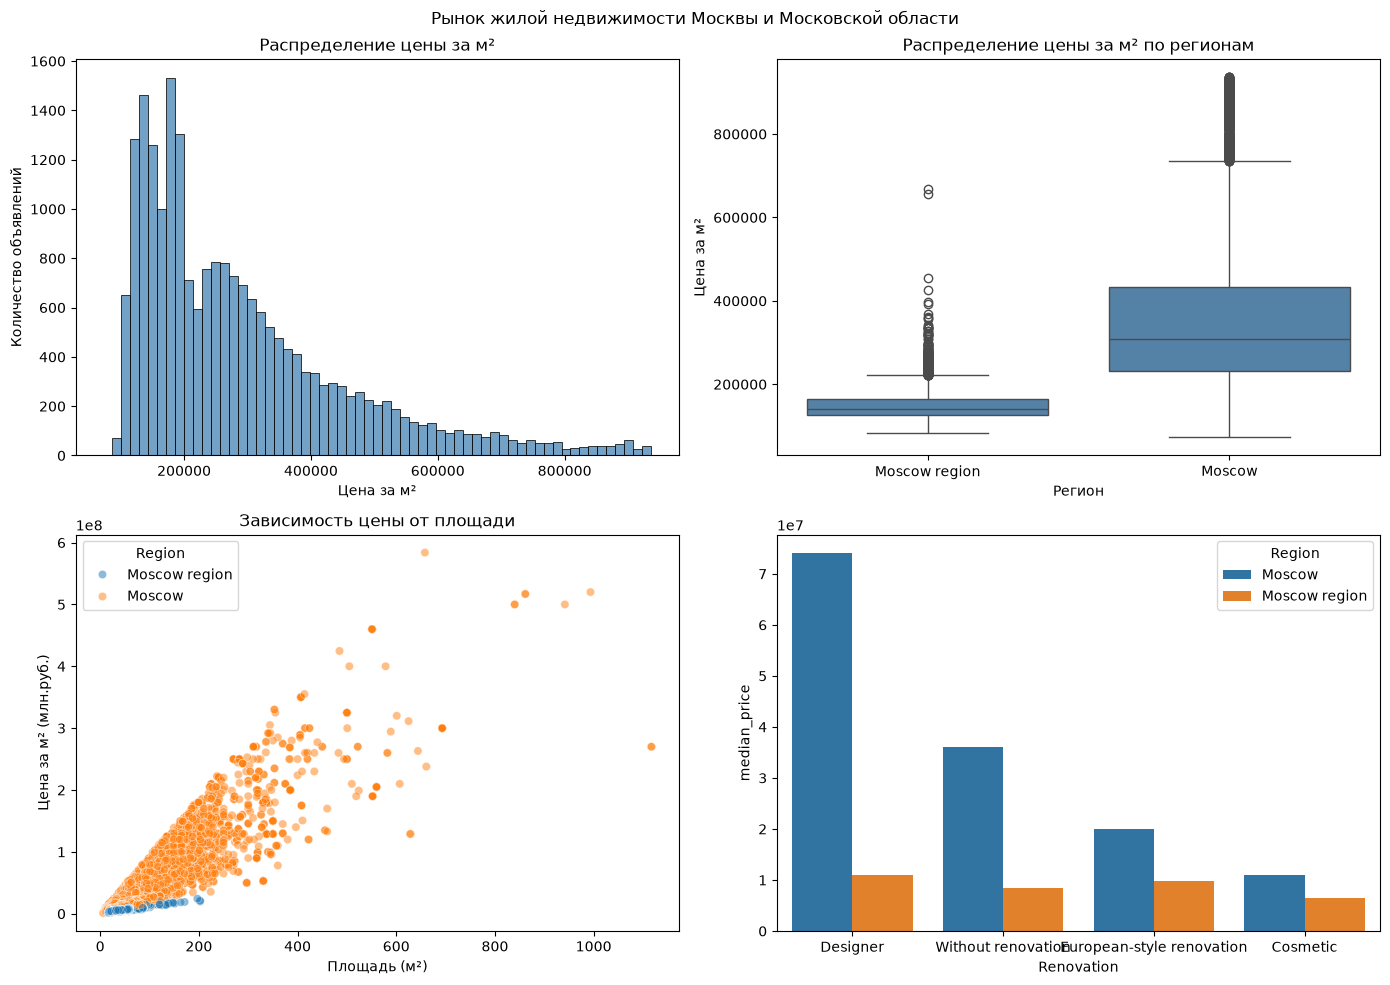

In [48]:
#Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

price_limit = work["Price per sqm"].quantile(0.95)

price_plot = work[
    work["Price per sqm"] <= price_limit
]
sns.histplot(data=price_plot,x="Price per sqm",ax=axes[0,0],color="steelblue")
axes[0,0].set_title('Распределение цены за м²')
axes[0,0].set_xlabel('Цена за м²')
axes[0,0].set_ylabel('Количество объявлений')

sns.boxplot(data=price_plot,y="Price per sqm",x='Region',ax=axes[0,1],color="steelblue")
axes[0,1].set_title('Распределение цены за м² по регионам')
axes[0,1].set_xlabel('Регион')
axes[0,1].set_ylabel('Цена за м²')

sns.scatterplot(data=price_plot,x="Area",y="Price",hue="Region",alpha=0.5,ax=axes[1, 0])
axes[1,0].set_title('Зависимость цены от площади')
axes[1,0].set_xlabel('Площадь (м²)')
axes[1,0].set_ylabel('Цена за м² (млн.руб.)')

sns.barplot(
    data=renovation_stats,
    x="Renovation",
    y="median_price",
    hue="Region",
    ax=axes[1, 1]
)

fig.suptitle(
    "Рынок жилой недвижимости Москвы и Московской области"
)
plt.tight_layout()

plt.savefig(
    "housing_market_report.png",
    dpi=500,
    bbox_inches="tight"
)

In [55]:
#Найти типичное предложение для заданного покупателя
#Предположим, покупатель ищет:
#    - квартиру в Москве;
#    - 2 комнаты;
#    - площадь от 50 до 80 м²;
#    - не более 15 минут до метро

In [53]:
mask = (
    (work['Region']=='Moscow')&
    (work['Number of rooms']==2)&
    (work['Area']>=50)&
    (work['Area']<=80)&   
    (work['Minutes to metro']<=15)& 
    work["Floor valid"]
)

selected = work[mask].round(2)
selected.nsmallest(5,'Price per sqm')

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation,Price per sqm,Living share,Floor valid,Floor share,Metro group
13683,8800000.0,New building,Царицыно,3.0,Moscow,2.0,61.60,33.3,11.7,3.0,13,Cosmetic,142857.14,0.54,True,0.23,до 5 мин
16820,8900000.0,New building,Марьино,7.0,Moscow,2.0,61.00,25.5,22.3,3.0,15,Cosmetic,145901.64,0.42,True,0.20,5–10 мин
13579,10194450.0,New building,Братиславская,13.0,Moscow,2.0,69.35,28.1,21.3,15.0,16,Cosmetic,147000.00,0.41,True,0.94,10–20 мин
13582,9333000.0,New building,Братиславская,13.0,Moscow,2.0,62.22,32.1,10.7,16.0,16,Cosmetic,150000.00,0.52,True,1.00,10–20 мин
13898,9796400.0,New building,Братиславская,13.0,Moscow,2.0,64.45,32.6,14.2,15.0,16,Cosmetic,152000.00,0.51,True,0.94,10–20 мин


In [51]:
segments.to_csv(
    "housing_segments.csv",
    index=False,
    encoding="utf-8-sig"
)